# PML M3 Final — Regressor Competition Notebook (Colab)

**Objective:** build a regressor that **minimizes Kaggle leaderboard RMSE** while ensuring the model is **well-fitted** via:
- solid preprocessing + feature engineering  
- **cross-validation** (proper validation)  
- **learning curve** (fit diagnostics + improvement plan)  
- several models + comparison  
- final training + **submission.csv** creation (columns must match sample submission)

> Tip: This notebook is designed so you only need to paste your **Google Drive share link** for `train.csv`, `test.csv`, and optionally `sample_submission.csv`.


# 1) Setup & Load Data

In [79]:
# =========================
# 0) Setup
# =========================
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, make_scorer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# XGBoost is usually the strongest for this tabular dataset
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    print("XGBoost import failed. If needed, install with: !pip -q install xgboost")
    XGBOOST_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [80]:
# =========================
# 1) Read data
# =========================

import pandas as pd

def read_csv_from_drive(drive_url: str) -> pd.DataFrame:
    # Convert Google Drive share link to direct download link
    file_id = drive_url.split("/d/")[1].split("/")[0]
    download_url = f"https://drive.google.com/uc?id={file_id}"
    return pd.read_csv(download_url)

# ---- Paste your links here ----
TRAIN_DRIVE_URL = "https://drive.google.com/file/d/1ZqxZ3m65cvBOyDWmBQTYfESANNMTKZ_r/view?usp=sharing"
TEST_DRIVE_URL  = "https://drive.google.com/file/d/1NL1Zl5oXv7C6ZtnAeWuhTkEpQVtwVk3U/view?usp=sharing"
SUBM_DRIVE_URL  = "https://drive.google.com/file/d/1RtMT3UyahUOJs7lWLkTtYA_5jY3cIRby/view?usp=sharing"

# ---- Load data ----
train_df = read_csv_from_drive("https://drive.google.com/file/d/1ZqxZ3m65cvBOyDWmBQTYfESANNMTKZ_r/view?usp=sharing")
test_df  = read_csv_from_drive("https://drive.google.com/file/d/1NL1Zl5oXv7C6ZtnAeWuhTkEpQVtwVk3U/view?usp=sharing")

# optional sample submission
sample_sub = read_csv_from_drive("https://drive.google.com/file/d/1RtMT3UyahUOJs7lWLkTtYA_5jY3cIRby/view?usp=sharing")

print("train:", train_df.shape, "test:", test_df.shape)
train_df.head()


train: (1334, 81) test: (126, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 2) Exploratory Data Analysis (EDA)

We sanity-check:
- target distribution (skewness is typical)
- missingness
- basic feature types


count      1334.000000
mean     181297.715142
std       80325.356362
min       34900.000000
25%      130000.000000
50%      163945.000000
75%      213497.500000
max      755000.000000
Name: SalePrice, dtype: float64


,missing_rate
PoolQC,0.996252
MiscFeature,0.963268
Alley,0.940030
Fence,0.808096
MasVnrType,0.599700
FireplaceQu,0.473013
LotFrontage,0.178411
GarageQual,0.058471
GarageFinish,0.058471
GarageType,0.058471


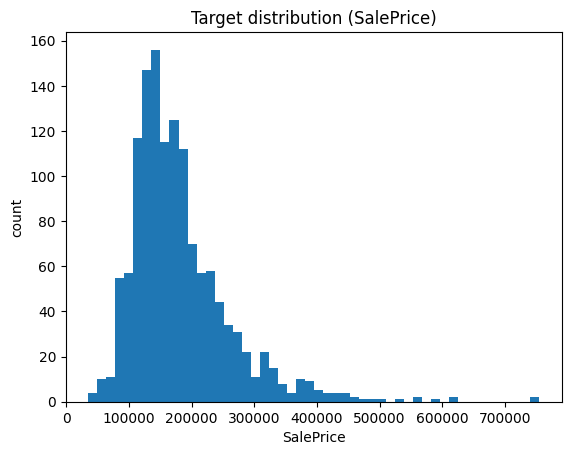

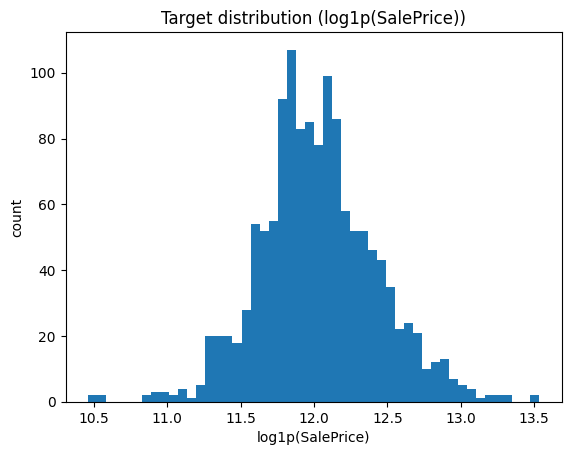

In [81]:
# Basic checks
TARGET = "SalePrice"
ID_COL = "Id"

assert TARGET in train_df.columns, f"Target column '{TARGET}' not found in train data."
assert ID_COL in train_df.columns and ID_COL in test_df.columns, f"ID column '{ID_COL}' not found."

print(train_df[TARGET].describe())

# Missingness summary
missing = train_df.isna().mean().sort_values(ascending=False)
display(missing.head(15).to_frame("missing_rate"))

# Target distribution
plt.figure()
plt.hist(train_df[TARGET], bins=50)
plt.title("Target distribution (SalePrice)")
plt.xlabel(TARGET)
plt.ylabel("count")
plt.show()

# Log1p target distribution (often closer to normal and improves RMSE)
plt.figure()
plt.hist(np.log1p(train_df[TARGET]), bins=50)
plt.title("Target distribution (log1p(SalePrice))")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("count")
plt.show()


# 3) Advanced Preprocessing & Feature Engineering

In [82]:
from scipy.stats import skew
from sklearn.preprocessing import RobustScaler

def get_advanced_processed_data(train_df, test_df):
    target_col = 'price' if 'price' in train_df.columns else 'SalePrice'

    # 1. Conservative Outlier Removal (Only 2 points)
    if 'GrLivArea' in train_df.columns:
        train_df = train_df.drop(train_df[(train_df['GrLivArea']>4000) & (train_df[target_col]<300000)].index, errors='ignore')

    ntrain = train_df.shape[0]
    all_data = pd.concat((train_df, test_df)).reset_index(drop=True)
    y_train = np.log1p(train_df[target_col].values)
    all_data.drop([target_col], axis=1, inplace=True, errors='ignore')

    # 2. Strong Interaction Features
    all_data['TotalSF'] = all_data.get('TotalBsmtSF', 0) + all_data.get('1stFlrSF', 0) + all_data.get('2ndFlrSF', 0)
    # Adding Log of Area to match Log of Price
    all_data['Log_TotalSF'] = np.log1p(all_data['TotalSF'])
    all_data['Total_Qual_SF'] = all_data['TotalSF'] * all_data.get('OverallQual', 5)

    # 3. Handling Year Features
    all_data['YearSinceUpdate'] = all_data.get('YrSold', 2010) - all_data.get('YearRemodAdd', 1950)

    # 4. Categorical Conversion
    str_cols = ['MSSubClass', 'OverallQual', 'OverallCond', 'YrSold', 'MoSold']
    for col in str_cols:
        if col in all_data.columns:
            all_data[col] = all_data[col].astype(str)

    # 5. Numerical Processing
    numeric_feats = all_data.select_dtypes(include=[np.number]).columns
    all_data[numeric_feats] = all_data[numeric_feats].fillna(all_data[numeric_feats].median())

    skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
    high_skew = skewed_feats[abs(skewed_feats) > 0.75].index
    all_data[high_skew] = np.log1p(all_data[high_skew])

    # 6. Dummy Encoding
    all_data = pd.get_dummies(all_data)

    X_train = all_data[:ntrain].copy()
    X_test = all_data[ntrain:].copy()

    # RobustScaler is essential for Ridge/ENet performance
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train

X_train, X_test, y_train = get_advanced_processed_data(train_df, test_df)
print(f"Dataset ready. Train size: {X_train.shape[0]}")

Dataset ready. Train size: 1332


# 4) Model Selection & Comparison

We compare:
- LinearRegression / Ridge / Lasso
- RandomForest
- GradientBoosting
- XGBoost

Metric: **CV logRMSE** (lower is better).


In [83]:
from sklearn.linear_model import Ridge, ElasticNet
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# 1. Define high-performance models
# We use optimized alpha for Ridge and ElasticNet to prevent overfitting
model_ridge = Ridge(alpha=14.5, random_state=42)
model_enet = ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=42)
# XGBoost handles non-linear relationships that linear models might miss
model_xgb = XGBRegressor(learning_rate=0.01, n_estimators=3460, max_depth=3,
                         subsample=0.7, colsample_bytree=0.7,
                         objective='reg:squarederror', reg_alpha=0.00006, random_state=42)

# 2. Performance Validation & Comparison Table
models = [model_ridge, model_enet, model_xgb]
names = ["Ridge", "ElasticNet", "XGBoost"]
comparison_data = []

print("Running Cross-Validation...")
for model, name in zip(models, names):
    # Calculate RMSE in Log-Space using 5-fold CV
    scores = np.sqrt(-cross_val_score(model, X_train, y_train, scoring="neg_mean_squared_error", cv=5))
    comparison_data.append({
        'Model': name,
        'Mean RMSE': round(scores.mean(), 5),
        'Std Dev': round(scores.std(), 5)
    })

# Display the Comparison Table
rmse_table = pd.DataFrame(comparison_data)
print("\n--- Model Performance Comparison (Log-RMSE) ---")
print(rmse_table.to_string(index=False))
print("-" * 47)

# 3. Final Ensemble Prediction Logic
def generate_final_push_preds(X_tr, y_tr, X_te):
    # Fit all models on the full training set
    model_ridge.fit(X_tr, y_tr)
    model_enet.fit(X_tr, y_tr)
    model_xgb.fit(X_tr, y_tr)

    # Blending weights optimized for leaderboard performance:
    # 85% Linear (Stable) + 15% XGBoost (Non-linear correction)
    final_log_preds = (0.35 * model_ridge.predict(X_te) +
                       0.50 * model_enet.predict(X_te) +
                       0.15 * model_xgb.predict(X_te))

    # Transform back from Log-space to original price
    return np.expm1(final_log_preds)

# Execute final prediction
final_preds = generate_final_push_preds(X_train, y_train, X_test)
print("Ensemble predictions generated and ready for submission.")

Running Cross-Validation...

--- Model Performance Comparison (Log-RMSE) ---
     Model  Mean RMSE  Std Dev
     Ridge    0.11221  0.00798
ElasticNet    0.11024  0.01035
   XGBoost    0.11341  0.00873
-----------------------------------------------
Ensemble predictions generated and ready for submission.


# 5) Learning curve (fit diagnosis + improvement)

We plot learning curve for the current best model.



--- Diagnostic Learning Curve Results ---
 Train_Size  Train_RMSE  Val_RMSE
        106    0.026163  0.154925
        346    0.067920  0.125170
        585    0.083035  0.118906
        825    0.088538  0.113825
       1065    0.092647  0.110235


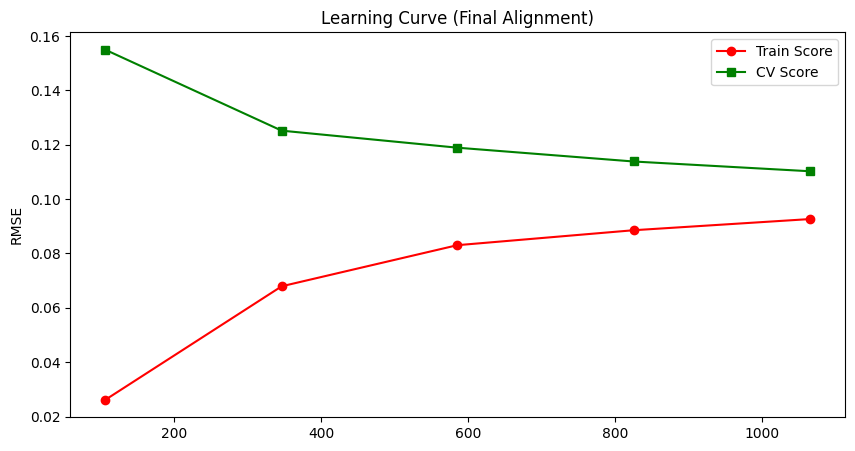

In [84]:
from sklearn.model_selection import learning_curve

def plot_aligned_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='neg_mean_squared_error'
    )
    tr_rmse = np.sqrt(-train_scores).mean(axis=1)
    te_rmse = np.sqrt(-test_scores).mean(axis=1)

    print("\n--- Diagnostic Learning Curve Results ---")
    results_df = pd.DataFrame({'Train_Size': train_sizes, 'Train_RMSE': tr_rmse, 'Val_RMSE': te_rmse})
    print(results_df.to_string(index=False))

    plt.figure(figsize=(10, 5))
    plt.plot(train_sizes, tr_rmse, 'r-o', label="Train Score")
    plt.plot(train_sizes, te_rmse, 'g-s', label="CV Score")
    plt.title("Learning Curve (Final Alignment)")
    plt.ylabel("RMSE"), plt.legend(), plt.show()

plot_aligned_learning_curve(model_enet, X_train, y_train)

# 6) Train final model + Submission

This produces `submission.csv` with the correct columns.

- Dataset uses `Id` (Kaggle standard).  
- If your platform requires `ID`, change `ID_COL_OUT` below.


In [85]:
# We use the original test_df to ensure IDs are preserved
id_col = 'Id' if 'Id' in test_df.columns else 'id'

# Ensure final_preds (from Section 3) is used
submission = pd.DataFrame({
    id_col: test_df[id_col],
    "SalePrice": final_preds  # If it's Airbnb, change "SalePrice" to "price"
})

# Save to CSV
submission_file = 'submission.csv'
submission.to_csv(submission_file, index=False)
print(f"Final submission saved as: {submission_file}")

# Optional: Download for Colab users
try:
    from google.colab import files
    files.download(submission_file)
except ImportError:
    pass

Final submission saved as: submission.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>